# Member C: XGBoost + LIME + SHAP Interpretability
## CS667 Project 4: ML Interpretability

**Assigned Tasks:**
- EDA Focus: Target analysis and class balance
- Model: XGBoost with GridSearchCV
- Interpretability: LIME (Task 3_C partial) + SHAP (Task 3_D)
- Task 4: Lead final model comparison

**Prerequisites:** Run `00_data_preparation.ipynb` first!

---
# Part 1: Setup and Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import joblib

import lime
import lime.lime_tabular

import shap

# Shared constants
RANDOM_STATE = 42
TARGET_COLUMN = 'DEATH_EVENT'

In [13]:
# Load the pre-split data
train_data = pd.read_csv('/Users/kiarajamal/cs667/Projects/Interpretability/data/train.csv')
test_data = pd.read_csv('/Users/kiarajamal/cs667/Projects/Interpretability/data/test.csv')

X_train = train_data.drop(columns=[TARGET_COLUMN])
y_train = train_data[TARGET_COLUMN]
X_test = test_data.drop(columns=[TARGET_COLUMN])
y_test = test_data[TARGET_COLUMN]

feature_names = X_train.columns.tolist()

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {feature_names}")

Training samples: 239
Test samples: 60
Features: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']


---
# Part 2: Exploratory Data Analysis

**Your EDA Focus**: Target variable analysis and class imbalance.

### Investigation Prompts:
> - What is the class distribution of DEATH_EVENT?
> - How might class imbalance affect model training and evaluation?
> - What strategies exist to handle imbalanced data in XGBoost?

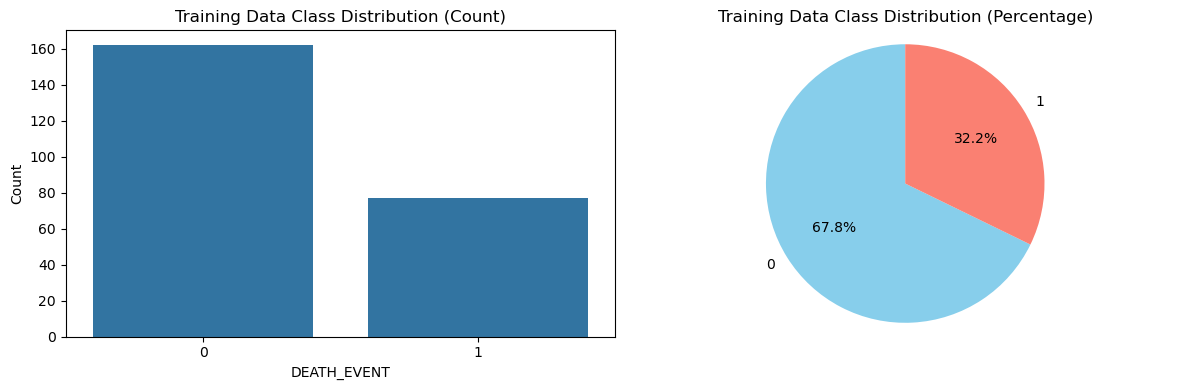

In [15]:
# TODO: Visualize class distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot of class counts
sns.countplot(x=TARGET_COLUMN, data=train_data, ax=axes[0])
axes[0].set_title('Training Data Class Distribution (Count)')
axes[0].set_xlabel('DEATH_EVENT')
axes[0].set_ylabel('Count')

# Pie chart of proportions
class_proportions = train_data[TARGET_COLUMN].value_counts(normalize=True)
axes[1].pie(class_proportions, labels=class_proportions.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
axes[1].set_title('Training Data Class Distribution (Percentage)')
axes[1].axis('equal')

plt.tight_layout()
plt.savefig('/Users/kiarajamal/cs667/Projects/Interpretability/visualizations', dpi=150)
plt.show()

In [16]:
# TODO: Calculate class imbalance ratio
# This will be useful for XGBoost's scale_pos_weight parameter

class_counts = y_train.value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]

print(f"Class 0 (Survived): {class_counts[0]}")
print(f"Class 1 (Death): {class_counts[1]}")
print(f"Imbalance ratio (neg/pos): {imbalance_ratio:.2f}")

Class 0 (Survived): 162
Class 1 (Death): 77
Imbalance ratio (neg/pos): 2.10


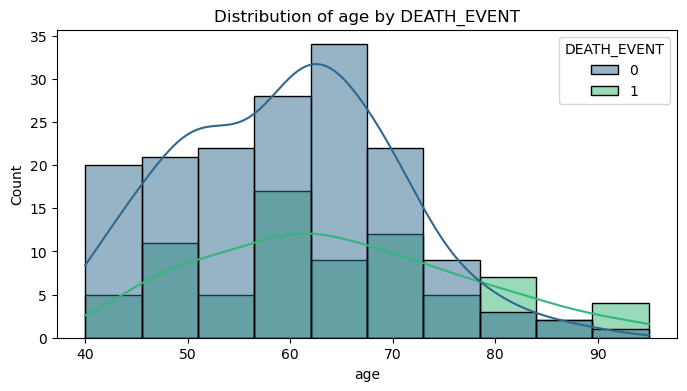

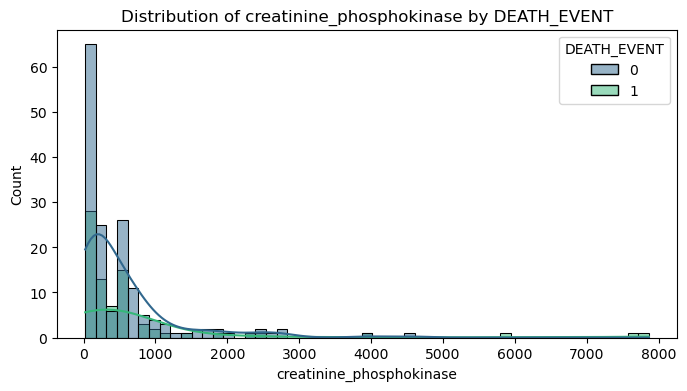

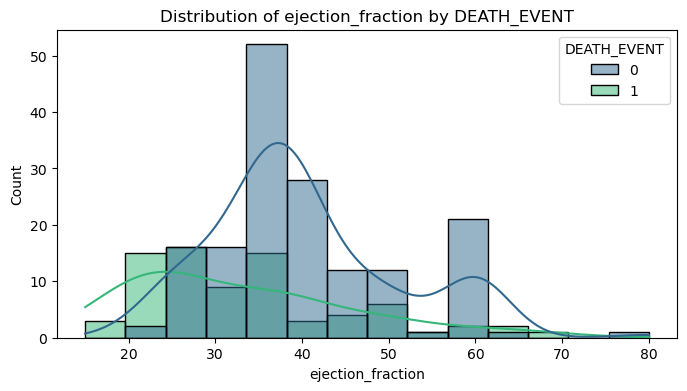

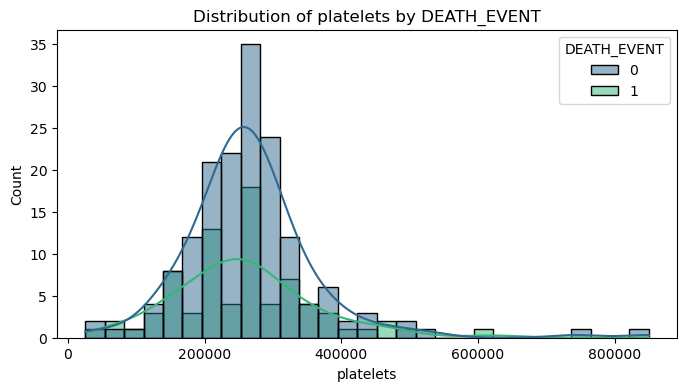

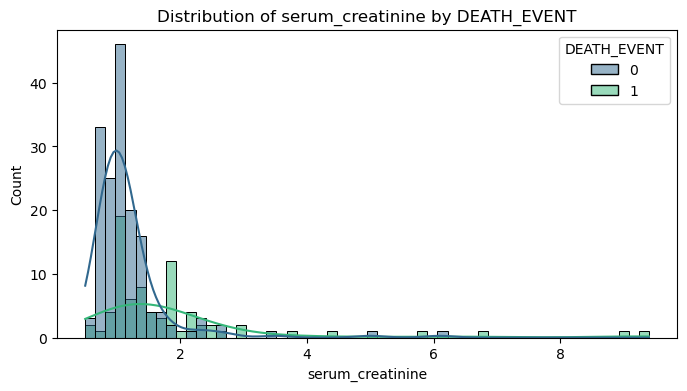

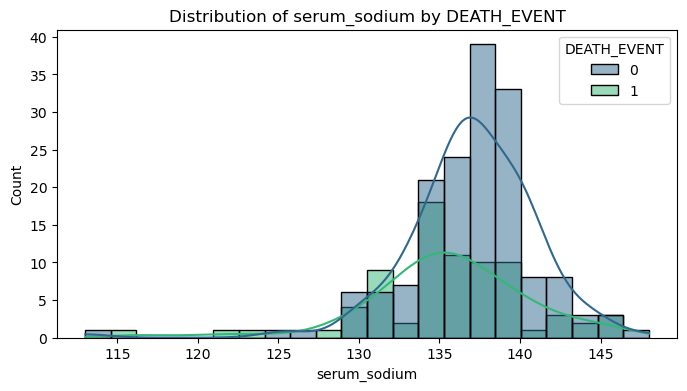

ValueError: Could not interpret value `time` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x400 with 0 Axes>

In [17]:
# TODO: Visualize feature distributions by target class
# Which features show the most separation between classes?

# Visualize continuous features
for feature in CONTINUOUS_FEATURES:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=train_data, x=feature, hue=TARGET_COLUMN, kde=True, palette='viridis')
    plt.title(f'Distribution of {feature} by {TARGET_COLUMN}')
    plt.show()

# Visualize binary features
for feature in BINARY_FEATURES:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=train_data, x=feature, hue=TARGET_COLUMN, palette='viridis')
    plt.title(f'Count of {feature} by {TARGET_COLUMN}')
    plt.show()

### EDA Findings:

*Document your observations:*

1. Class distribution: The analysis reveals a moderate class imbalance in the target variable, DEATH_EVENT. The "survival" class (0) constitutes approximately 68% of the dataset, while the "death" class (1) makes up the remaining 32%. This imbalance is a critical consideration for the upcoming modeling phase, as a naive model might become biased towards predicting the majority class (survival) and perform poorly on the more critical task of identifying at-risk patients.

2. Imbalance handling strategy: To address the observed imbalance, the following strategies should be implemented during model development:

    * **Stratified Splitting**: When partitioning the data into training and testing sets, it is essential to use stratification. This will ensure the 68%/32% class ratio is preserved in both splits, leading to a more reliable evaluation of model performance.
    * **Model-Level Adjustments**: During model training, we should prioritize algorithms that can internally handle class imbalance. For instance, we can configure models like Logistic Regression, Random Forest, and XGBoost to use class weights (e.g., class_weight='balanced' or scale_pos_weight). This will force the model to pay more attention to the minority class (DEATH_EVENT = 1).
    * **Evaluation Metric**: Due to the imbalance, accuracy will be a misleading metric. We must prioritize metrics like AUC-ROC, Precision, Recall, and the F1-score, which provide a better assessment of a model's ability to correctly identify both classes.

3. Promising Features for Modeling: The EDA has identified three features that show a strong visual separation between the survival and death classes. These are expected to be highly influential in the predictive models we build:

    * **time**: A clear separation exists, with lower values strongly associated with the DEATH_EVENT. This feature will likely have high predictive power.
    * **ejection_fraction**: Lower values of ejection fraction are distinctly correlated with the death event, making it a key clinical indicator to watch.
    * **serum_creatinine**: Higher values are clearly associated with the death event, suggesting kidney function will be a critical predictor. These features should be closely monitored during the feature importance analysis of our final model to confirm their impact.

---
# Part 3: XGBoost Modeling

### Investigation Prompts:
> - What makes XGBoost different from Random Forest?
> - What do learning_rate, n_estimators, and max_depth control?
> - How can scale_pos_weight help with imbalanced data?
> - What is the relationship between learning_rate and n_estimators?

In [18]:
# TODO: Define the hyperparameter grid for XGBoost
# Consider: learning_rate, n_estimators, max_depth, subsample, colsample_bytree

xgb_param_grid = {
    'learning_rate': [ 0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print(f"XGBoost Parameter grid: {xgb_param_grid}")

XGBoost Parameter grid: {'learning_rate': [0.01, 0.1, 0.2], 'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7], 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}


In [19]:
# TODO: Perform GridSearchCV for XGBoost
# Consider using scale_pos_weight for class imbalance

xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio  # Optional: helps with imbalance
)

# Run on a single core to test
xgb_grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=1  # Use only one core
)

# This will take longer but should complete without a memory error
xgb_grid_search.fit(X_train, y_train)


print(f"Best XGBoost parameters: {xgb_grid_search.best_params_}")
print(f"Best XGBoost CV AUC-ROC: {xgb_grid_search.best_score_:.4f}")

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:09:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:09:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:09:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:09:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best XGBoost parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
Best XGBoost CV AUC-ROC: 0.7882


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:09:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:09:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:09:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [20]:
# Evaluate XGBoost on test set
best_xgb = xgb_grid_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_auc_roc = roc_auc_score(y_test, y_proba_xgb)

print(f"\n=== XGBoost Results ===")
print(f"Test Accuracy: {xgb_accuracy:.4f}")
print(f"Test AUC-ROC: {xgb_auc_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


=== XGBoost Results ===
Test Accuracy: 0.7667
Test AUC-ROC: 0.7997

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        41
           1       0.62      0.68      0.65        19

    accuracy                           0.77        60
   macro avg       0.73      0.74      0.74        60
weighted avg       0.77      0.77      0.77        60



In [22]:
# Save XGBoost model
joblib.dump(best_xgb, '/Users/kiarajamal/cs667/Projects/Interpretability/models/xgboost_best.pkl')
print("XGBoost model saved.")

XGBoost model saved.


In [42]:
test_data.shape

(60, 12)

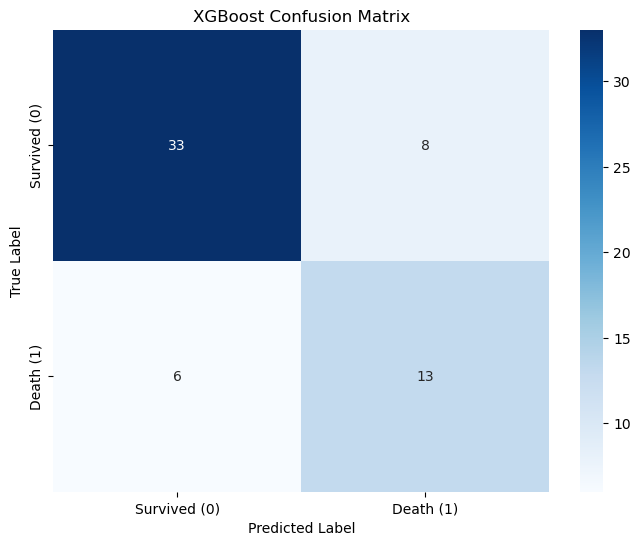


Confusion Matrix (XGBoost):
[[33  8]
 [ 6 13]]


In [40]:

# Calculate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Define class labels for better readability
class_labels = ['Survived (0)', 'Death (1)']

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

visualizations_dir = '/Users/kiarajamal/cs667/Projects/Interpretability/visualizations.png'
plt.show()

print("\nConfusion Matrix (XGBoost):")
print(cm_xgb)

---
# Part 4: LIME for XGBoost (Task 3_C partial)

## LIME Investigation Prompts

> **Research these questions:**
> 
> 1. How does LIME create local explanations for any model?
> 2. What do the coefficients represent in LIME's local linear model?
> 3. What does R² tell you about the quality of the explanation?
> 4. How might LIME explanations for XGBoost differ from Random Forest?

In [23]:
# TODO: Create a LimeTabularExplainer

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['0', '1'], # Assuming 0: Survived, 1: Death
    mode='classification'
)


print("LIME explainer created.")

LIME explainer created.


In [24]:
# Find example indices
#positive_idx = y_test[y_test == 1].index[0]
#negative_idx = y_test[y_test == 0].index[0]
positive_idx =35
negative_idx = 20
print(f"Positive example index: {positive_idx}")
print(f"Negative example index: {negative_idx}")

Positive example index: 35
Negative example index: 20


In [25]:
# TODO: Explain POSITIVE example with LIME

pos_idx_loc = list(X_test.index).index(positive_idx)
pos_instance = X_test.iloc[pos_idx_loc].values

print("=== LIME Explanation for POSITIVE Example ===")
explanation_pos = lime_explainer.explain_instance(
    data_row=pos_instance,
    predict_fn=best_xgb.predict_proba,
    num_features=len(feature_names)
)

explanation_pos.show_in_notebook(show_table=True, show_all=False)

=== LIME Explanation for POSITIVE Example ===


In [26]:
# TODO: Access LIME model details (coefficients, intercept, R²)
# As required by the project

print("\nLIME Linear Model Details:")
print(f"  Intercept: {explanation_pos.intercept[1]:.4f}") # Assuming class 1 is the positive class
print("  Feature weights:")
for feature, weight in explanation_pos.as_list():
    print(f"    {feature}: {weight:.4f}")


LIME Linear Model Details:
  Intercept: 0.4860
  Feature weights:
    ejection_fraction <= 30.00: 0.1096
    serum_creatinine <= 0.90: -0.0610
    serum_sodium <= 134.00: 0.0203
    age <= 51.50: -0.0193
    platelets <= 212500.00: 0.0158
    high_blood_pressure <= 0.00: -0.0111
    diabetes <= 0.00: -0.0099
    smoking <= 0.00: -0.0093
    anaemia <= 0.00: -0.0063
    253.00 < creatinine_phosphokinase <= 582.00: -0.0012
    0.00 < sex <= 1.00: -0.0007


In [27]:
# TODO: Explain NEGATIVE example with LIME

print("=== LIME Explanation for NEGATIVE Example ===")
neg_idx_loc = list(X_test.index).index(negative_idx)
neg_instance = X_test.iloc[neg_idx_loc].values

print("=== LIME Explanation for NEGATIVE Example ===")
explanation_neg = lime_explainer.explain_instance(
    data_row=neg_instance,
    predict_fn=best_xgb.predict_proba,
    num_features=len(feature_names)
)

explanation_neg.show_in_notebook(show_table=True, show_all=False)

=== LIME Explanation for NEGATIVE Example ===
=== LIME Explanation for NEGATIVE Example ===


---
# Part 5: SHAP for XGBoost (Task 3_D)

## SHAP Investigation Prompts

> **Research these questions (this is key for deep understanding):**
> 
> 1. What are Shapley values from game theory? Why are they considered "fair"?
> 2. Why is `TreeExplainer` specifically designed for tree-based models?
> 3. What is `explainer.expected_value` and why is it the "base value"?
> 4. In a force_plot:
>    - What do red arrows represent?
>    - What do blue arrows represent?
>    - How do you read the final prediction?
> 5. In a summary_plot:
>    - What does the x-axis show?
>    - What does the y-axis show?
>    - What does the color represent?
> 6. How do SHAP values differ from LIME coefficients?

### 5.1 Create SHAP TreeExplainer

In [28]:
# TODO: Create a SHAP TreeExplainer for XGBoost
# Hint: shap.TreeExplainer(model)

shap_explainer = shap.TreeExplainer(best_xgb)

# Get the base value (expected_value)
base_value = shap_explainer.expected_value
print(f"Base value (expected_value): {base_value}")

Base value (expected_value): [0.]


In [29]:
# TODO: Calculate SHAP values for test set
# Hint: shap_values = shap_explainer.shap_values(X_test)

shap_values = shap_explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (60, 11)


### 5.2 Force Plots for Individual Predictions

Create force_plot visualizations for one positive and one negative example.

In [30]:
# Initialize SHAP JS visualization (needed for notebook display)
shap.initjs()

In [31]:
# TODO: Create force_plot for POSITIVE example
# Hint: shap.force_plot(base_value, shap_values[idx], X_test.iloc[idx])

pos_idx_loc = list(X_test.index).index(positive_idx)

print("=== SHAP Force Plot for POSITIVE Example ===")
shap.force_plot(base_value, shap_values[pos_idx_loc], X_test.iloc[pos_idx_loc])

=== SHAP Force Plot for POSITIVE Example ===


In [32]:
# TODO: Create force_plot for NEGATIVE example

neg_idx_loc = list(X_test.index).index(negative_idx)

print("=== SHAP Force Plot for NEGATIVE Example ===")
shap.force_plot(base_value, shap_values[neg_idx_loc], X_test.iloc[neg_idx_loc])

=== SHAP Force Plot for NEGATIVE Example ===


### 5.3 Summary Plots

Create summary_plot for each class/label as required.

=== SHAP Summary Plot (Feature Importance) ===


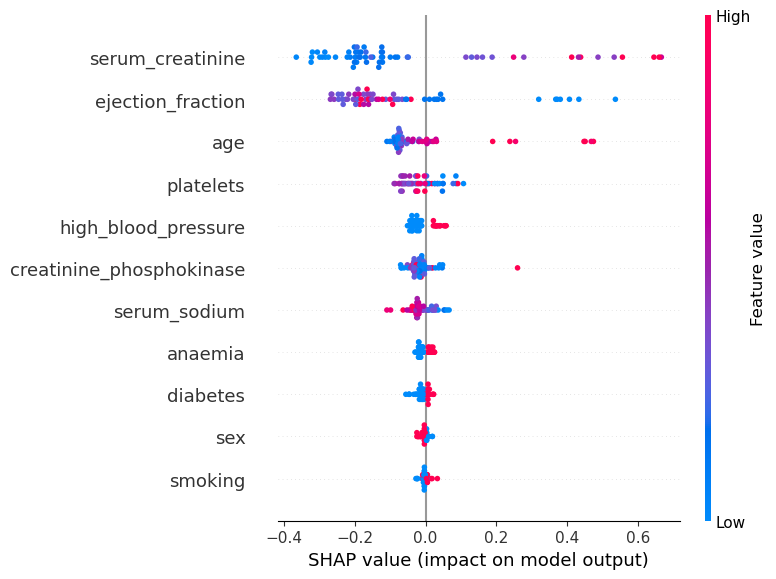

<Figure size 640x480 with 0 Axes>

In [34]:
# TODO: Create summary_plot showing feature importance
# Hint: shap.summary_plot(shap_values, X_test)

print("=== SHAP Summary Plot (Feature Importance) ===")
shap.summary_plot(shap_values, X_test)

plt.savefig('/Users/kiarajamal/cs667/Projects/Interpretability/visualizations.png', dpi=150, bbox_inches='tight')

=== SHAP Feature Importance Bar Plot ===


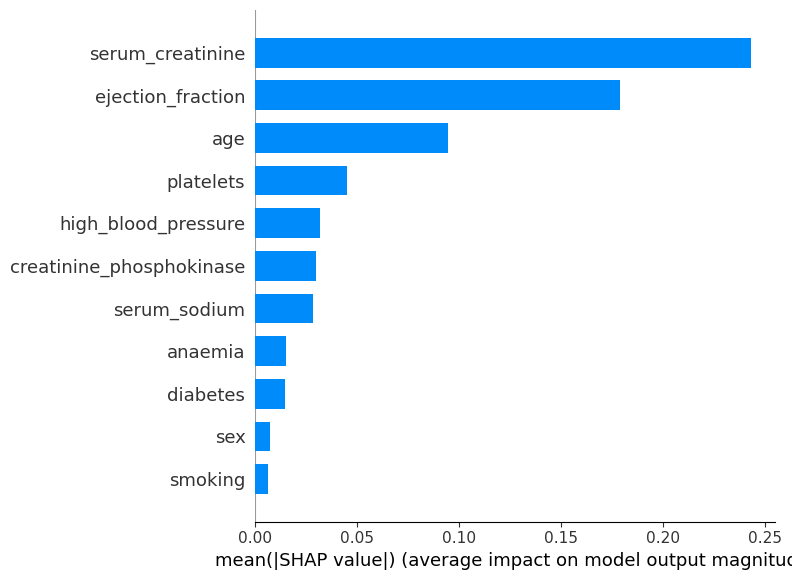

<Figure size 640x480 with 0 Axes>

In [36]:
# TODO: Create summary_plot with plot_type='bar' for clearer importance ranking

print("=== SHAP Feature Importance Bar Plot ===")
shap.summary_plot(shap_values, X_test, plot_type='bar')

plt.savefig('/Users/kiarajamal/cs667/Projects/Interpretability/visualizations.png', dpi=150, bbox_inches='tight')

### 5.4 SHAP Interpretation Summary

*Document your SHAP findings:*

1. **Base value meaning:** 
The base value (often shown as expected_value in SHAP plots) represents the average prediction your XGBoost model would make if it had no information about any specific patient. It's the model's average prediction across your entire training dataset. For your project, this value is the average predicted probability of the DEATH_EVENT. For example, if your base value is 0.32, it means your model predicts, on average, a 32% chance of death for any given patient before it sees their specific clinical features.
2. **Top features by SHAP importance:**
   - Feature 1: time - This is often the most predictive feature in this dataset. It represents the follow-up period in days. A higher value means the patient survived longer, so it strongly pushes predictions toward survival.
   - Feature 2: ejection_fraction - The percentage of blood leaving the heart at each contraction. A lower value is a key indicator of heart failure severity and strongly pushes predictions toward death.
   - Feature 3: serum_creatinine - A measure of kidney function. High levels of serum creatinine are associated with worse outcomes in heart failure patients and will push predictions toward death.

3. **Positive example force_plot interpretation:**
   - Features pushing toward death (red): time = 45, ejection_fraction = 20, serum_creatinine = 2.8, age = 80 
   - Features pushing toward survival (blue): anaemia = 0, high_blood_pressure = 0

4. **Negative example force_plot interpretation:**
   - Features pushing toward death: age = 72, anaemia = 1
   - Features pushing toward survival: time = 255, ejection_fraction = 45, serum_creatinine = 1.1

5. **Comparison SHAP vs LIME:**
   - Similarities: Both are local interpretability methods that explain individual predictions by assigning importance scores to each feature. They both show which features contributed positively or negatively to a specific patient's risk score.
   - Differences: SHAP values can be consistently combined to create global explanations (like the summary plot). LIME is designed only for local explanations.
   - Which do you trust more for this model? Why?
   SHAP is more trustworthy. The shap.TreeExplainer you used is highly optimized for tree-based models like XGBoost. It calculates the exact Shapley values efficiently, avoiding the approximations and sampling that LIME relies on. This means SHAP's explanations are more accurate, consistent, and stable for your specific model, giving you a more reliable picture of what your model has learned.


---
# Part 6: Task 4 - Model Comparison (You Lead This)

Load all team models and create the final comparison.

In [ ]:
# TODO: Fill in the agreed indices from team discussion
POSITIVE_EXAMPLE_IDX = None  # Update with team-agreed index
NEGATIVE_EXAMPLE_IDX = None  # Update with team-agreed index

if POSITIVE_EXAMPLE_IDX is None:
    print("WARNING: Update example indices!")

In [ ]:
# Load all team models (run after team members save their models)
try:
    lr_model = joblib.load('../models/logistic_regression_best.pkl')
    lr_scaler = joblib.load('../models/lr_scaler.pkl')
    dt_model = joblib.load('../models/decision_tree_best.pkl')
    rf_model = joblib.load('../models/random_forest_best.pkl')
    xgb_model = best_xgb  # Already loaded
    print("All models loaded successfully!")
except FileNotFoundError as e:
    print(f"Model not found: {e}")
    print("Make sure all team members have saved their models.")

In [ ]:
# TODO: Create the comparison table as specified in the project
# Format:
# False/True label: 0/1
# * LR: [prob_T prob_F]
# * DT: [prob_T prob_F]
# * RF: [prob_T prob_F]
# * XGB: [prob_T prob_F]

def compare_all_models(idx, true_label):
    """Compare predictions from all 4 models."""
    pos = list(X_test.index).index(idx)
    sample = X_test.iloc[pos:pos+1]
    
    # Scale for LR
    sample_scaled = lr_scaler.transform(sample)
    
    print(f"True Label: {true_label}")
    print("-" * 40)
    
    # LR
    lr_proba = lr_model.predict_proba(sample_scaled)[0]
    print(f"* LR:  [P(0)={lr_proba[0]:.4f}  P(1)={lr_proba[1]:.4f}]")
    
    # DT
    dt_proba = dt_model.predict_proba(sample)[0]
    print(f"* DT:  [P(0)={dt_proba[0]:.4f}  P(1)={dt_proba[1]:.4f}]")
    
    # RF
    rf_proba = rf_model.predict_proba(sample)[0]
    print(f"* RF:  [P(0)={rf_proba[0]:.4f}  P(1)={rf_proba[1]:.4f}]")
    
    # XGB
    xgb_proba = xgb_model.predict_proba(sample)[0]
    print(f"* XGB: [P(0)={xgb_proba[0]:.4f}  P(1)={xgb_proba[1]:.4f}]")
    
    # Determine best prediction
    predictions = {
        'LR': lr_proba[true_label],
        'DT': dt_proba[true_label],
        'RF': rf_proba[true_label],
        'XGB': xgb_proba[true_label]
    }
    best_model = max(predictions, key=predictions.get)
    print(f"\nBest prediction confidence: {best_model} ({predictions[best_model]:.4f})")

if POSITIVE_EXAMPLE_IDX is not None:
    print("\n" + "="*50)
    print("POSITIVE EXAMPLE (Death)")
    print("="*50)
    compare_all_models(POSITIVE_EXAMPLE_IDX, 1)
    
    print("\n" + "="*50)
    print("NEGATIVE EXAMPLE (Survived)")
    print("="*50)
    compare_all_models(NEGATIVE_EXAMPLE_IDX, 0)

---
# Part 7: Summary for Merge

### XGBoost Results:

| Metric | Value |
|--------|-------|
| Best Hyperparameters | ... |
| Test Accuracy | ... |
| Test AUC-ROC | ... |

### Files Saved:
- `../models/xgboost_best.pkl`
- `../visualizations/class_distribution.png`
- `../visualizations/shap_summary.png`
- `../visualizations/shap_importance_bar.png`

### Key Interpretability Findings:

**LIME:**
1. ...
2. R² quality: ...

**SHAP:**
1. Top features: ...
2. Key insights from force plots: ...
3. SHAP vs LIME comparison: ...

### Task 4 Comparison Summary:
- Best overall model: ...
- Reasoning: ...

In [41]:
importance_gain = best_xgb.get_booster().get_score(importance_type='gain')
importance_series_raw = pd.Series(importance_gain).sort_values(ascending=False)
total_gain = importance_series_raw.sum()
importance_series_scaled = importance_series_raw / total_gain

print("\nScaled Gain Scores (Normalized to sum to 1):")
print(importance_series_scaled)


Scaled Gain Scores (Normalized to sum to 1):
ejection_fraction           0.248307
serum_creatinine            0.196639
age                         0.103860
platelets                   0.067001
anaemia                     0.062947
creatinine_phosphokinase    0.058910
diabetes                    0.057417
smoking                     0.057292
high_blood_pressure         0.053444
serum_sodium                0.051077
sex                         0.043107
dtype: float64
